# Generowanie opisów obrazów – Show and Tell (2014)

Projekt realizowany w ramach przedmiotu _Analiza danych obrazowych i multimedialnych_ na Politechnice Warszawskiej.  
**Zespół projektowy:** Michał Suchocki, Piotr Szczerba, Krzysztof Rudnik, Krzysztof Dąbrowski  
**Realizacja:** 2026-06-02

<a href="https://github.com/christopher-dabrowski/Show-and-Tell" target="_blank" rel="noopener noreferrer">
  <div style="display:inline-flex; align-items:center; gap:8px;">
    <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" alt="GitHub" width="16" style="vertical-align:middle;" />
    Repozytorium
    <img alt="GitHub commits since tagged version" src="https://img.shields.io/github/commits-since/christopher-dabrowski/Show-and-Tell/forked?style=for-the-badge">
  </div>
</a>


# Spis treści
- [Omówienie metody Show and Tell](#omowienie-metody-show-and-tell)
  - [Ekstraktor cech](#ekstraktor-cech)
  - [Dekoder](#dekoder)
  - [Beam Search](#beam-search)
- [Omówienie wykorzystanej implementacji](#omowienie-wykorzystanej-implementacji)
  - [Uruchomienie projektu](#uruchomienie-projektu)
  - [Struktura repozytorium](#struktura-repozytorium)
  - [Implementacja modelu](#implementacja-modelu)
- [Wyniki działania](#wyniki-dzialania)
  - [Porównanie metod dekodowania - Greedy Search vs. Beam Search](#porownanie-metod-dekodowania---greedy-search-vs-beam-search)
    - [Ewaluacja](#ewaluacja)
    - [Wyniki: krzywa BLEU-4 w funkcji rozmiaru wiązki](#wyniki-krzywa-bleu-4-w-funkcji-rozmiaru-wiazki)
    - [Analiza jakościowa: Demonstracja przypadków gdzie jest największa różnica pomiędzy Beam Search a Greedy Search](#analiza-jakosciowa-demonstracja-przypadkow-gdzie-jest-najwieksza-roznica-pomiedzy-beam-search-a-greedy-search)
    - [Wnioski](#wnioski)
  - [Wizualizacja mechanizmu uwagi](#wizualizacja-mechanizmu-uwagi)
    - [Analiza: wygenerowane opisy i mapy uwagi](#analiza-wygenerowane-opisy-i-mapy-uwagi)
    - [Wnioski](#wnioski-1)
- [Krytyczna analiza](#krytyczna-analiza)
- [Wnioski](#wnioski-2)

<a id="omowienie-metody-show-and-tell"></a>
# Omówienie metody Show and Tell
<!-- krótko, zwięźle: do czego słuzy, na czym polega, podać linki do bardziej szczegółowych omówień, tutoriali, do repozytoriów kodu -->

Model Show and Tell jest jednym z pierwszych skutecznych podejść do **automatycznego generowania opisów tekstowych na podstawie obrazów**. Architektura **łączy sieć konwolucyjną**, która pełni rolę ekstraktora cech wizualnych, **z siecią rekurencyjną** odpowiedzialną za generowanie sekwencji słów opisujących obraz.
Wektor cech obrazu jest wykorzystywany jako wejście modelu językowego, który przewiduje kolejne słowa opisu w sposób sekwencyjny. Dzięki temu możliwe jest automatyczne tworzenie zdań opisujących zawartość sceny, obecne obiekty oraz relacje między nimi. Model został wytrenowany na dużych zbiorach zawierających obrazy wraz z opisami tekstowymi, co pozwoliło mu nauczyć się powiązań między reprezentacją wizualną a językiem naturalnym. Podejście to zapoczątkowało intensywny rozwój metod multimodalnych łączących analizę obrazu i przetwarzanie języka naturalnego. Zadanie generowania opisów obrazów jest szczególnie wymagające, ponieważ wymaga zarówno rozpoznania obiektów, jak i zrozumienia ich kontekstu. Analiza tego modelu pozwala zrozumieć sposób integracji reprezentacji wizualnych z modelami sekwencyjnymi oraz podstawy współczesnych systemów multimodalnych.

Szczegółowy opis metody przedstawia oryginalna publikacja [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/pdf/1411.4555).
Nasze eksperymenty prowadziliśmy w oparciu o tutorial [a PyTorch Tutorial to Image Captioning](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning). Zawiera ciekawe i rzetelne wyjaśnienie metody Show and Tell rozbudowanej o mechanizm uwagi.


![Schemat działania Show and Tell](img/overview_fig_2.png)  
Schemat działania metody Show and Tell  
_Źródło: [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/pdf/1411.4555)_

<a id="ekstraktor-cech"></a>
## Ekstraktor cech

Ekstraktor cech, nazywany również koderem, odpowiada za przetworzenie obrazu wejściowego na tensor zawierający informacje potrzebne to wygenerowania opisu przez dalszy model. Zazwyczaj używa się do tego sieci konwolucyjnej, ponieważ stan technologii do tego czasu wykazał, że sieci tego typu są skuteczne w klasyfikacji obrazów, autorzy założyli, że w takim razie sieci konwolucyjne będą również skuteczne w ekstrakcji cech potrzebnych do generowania opisów.

Przykładowo dla sieci konwolucyjnej ResNet-101 transformacja wygląda następująco:

![Ekstraktor cech](img/encoder_pl.png)

W przeciwieństwie do typowego zastosowania sieci konwolucyjnej, gdzie na końcu znajduje się warstwa klasyfikacyjna, w modelu Show and Tell wykorzystuje się wyjście z warstwy konwolucyjnej przed warstwą klasyfikacyjną. Wystarczy **usunąć warstwę klasyfikacyjną**.

<a id="dekoder"></a>
## Dekoder

Rolą dekodera jest wygenerowanie opisu tekstowego na podstawie cech obrazu. W modelu Show and Tell wykorzystuje się do tego sieć rekurencyjną, a dokładniej LSTM (Long Short-Term Memory).

![Decoder bez uwagi](./img/decoder_no_att_pl.png)

Bazowa praca nie uwzględnia mechanizmu uwagi, jednak tutorial, z którego korzystaliśmy korzysta z tego podejścia, więc w naszych eksperymentach wykorzystujemy dekoder z mechanizmem uwagi.

<a id="beam-search"></a>
## Beam Search

Zamiast wybierania jedynie najbardziej prawdopodobnego słowa na każdym kroku, użyta została metoda Beam Search, która pozwala na eksplorację wielu potencjalnych sekwencji jednocześnie. W każdym kroku generowania opisu utrzymuje się k najlepszych częściowych tłumaczeń, zwanych hipotezami. Na końcu wybierana jest sekwencja o najwyższym łącznym prawdopodobieństwie, co prowadzi do znalezienia bardziej optymalnego opisu niż w podejściu zachłannym.

![Beam Search](./img/beam_search.png)

<a id="omowienie-wykorzystanej-implementacji"></a>
# Omówienie wykorzystanej implementacji

Implementacja wykorzystana do naszych eksperymentów bazowała na tutorialu [a PyTorch Tutorial to Image Captioning](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning). Nasze repozytorium jest forkiem tego tutorialu.

Przygotowany model jest rozbudowany o mechanizm uwagi, który nie występuje w bazowej pracy [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/pdf/1411.4555). Na tak rozbudowanym modelu przeprowadziliśmy nasze badania. Mechanizm uwagi wykracza poza bazową metodę, jest jednak dobrze opisany w sekcji [Attention tutorialu](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning#attention), z którego korzystaliśmy.

<a id="uruchomienie-projektu"></a>
## Uruchomienie projektu

Do zarządzania wersją python oraz pakietami użyte zostało narzędzie [uv](https://docs.astral.sh/uv/). Jest napisane w Rust i jest znacznie szybsze od pozostałych opcji 😎

1. Zainstaluj `uv` zgodnie z [instrukcjami na stronie projektu](https://docs.astral.sh/uv/getting-started/installation/) (jeśli nie zainstalowałeś go wcześnie za pomocą `mise`).
2. Uruchom `uv sync` w katalogu projektu, aby zainstalować zależności i utworzyć środowisko wirtualne.
3. Jeżeli masz kartę graficzną serii RTX 50xx, zainstaluj odpowiednią wersję PyTorch: `uv pip install --force-reinstall --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128`
4. Pobierz [wagi modelu](https://drive.google.com/open?id=189VY65I_n4RTpQnmLGj7IzVnOF6dmePC) do katalogu `checkpoints/`, jeśli nie chcesz samodzielnie trenować modelu.
5. Pobierz i rozpakuj przygotowane dane [treningowe](http://images.cocodataset.org/zips/train2014.zip) i [walidacyjne](http://images.cocodataset.org/zips/val2014.zip) (zbiór COCO-2014) do katalogu `dataset/` tak, żeby powstały podfoldery `dataset/train2014/` i `dataset/val2014/`. Pobierz również plik podziału zbioru ("Karpathy split") [caption_datasets.zip](http://cs.stanford.edu/people/karpathy/deepimagesent/caption_datasets.zip) i rozpakuj go do `dataset/caption_datasets/` — potrzebny jest plik `dataset_coco.json`.
6. Uruchom `uv run create_input_files.py`, aby wygenerować dane wejściowe dla modelu. Domyślnie skrypt oczekuje pliku `dataset/caption_datasets/dataset_coco.json` i obrazów w `dataset/` - jeśli trzymasz dane w innych lokalizacjach, wskaż je flagami `--karpathy-json-path` i `--image-folder`. Wygenerowane pliki HDF5 i JSON trafią do katalogu `dataset/`.
7. Uruchom wybrany Jupyter Notebook korzystając z wirtualnego środowiska python jako kernela.

Bardziej rozbudowane instrukcje do pracy rozwojowej nad projektem opisaliśmy w [Readme](https://github.com/christopher-dabrowski/Show-and-Tell/blob/master/Readme.md).

<a id="struktura-repozytorium"></a>
## Struktura repozytorium

- Bazowe pliki tworzące model Show and Tell, takie jak `models.py`, `datasets.py`, `train.py` i `eval.py` pozwalające na trenowanie i testowanie modelu, są w bazowym katalogu repozytorium.
- `checkpoints/` zawiera zapisane wagi modelu po treningu. Z uwagi na duży rozmiar pliki te nie są przechowywane w repozytorium.
- `dataset/` zawiera przygotowane dane treningowe i testowe. Ze względu na duży rozmiar, podobnie jak w przypadku checkpointów, nie są one przechowywane w repozytorium.
- `eksperymenty/` zawiera notebooki z eksperymentami, w których testowaliśmy różne konfiguracje modelu i analizowaliśmy wyniki.
- `img/` zawiera obrazy używane w dokumentacji.
- `.github/workflows/` zawiera konfigurację GitHub Actions do automatycznej walidacji jakości kodu. Kod z wynikiem `pylint` poniżej 7 nie jest akceptowany.
- `pyproject.toml`, `uv.lock` i `.python-version` zawierają informacje o zależnościach projektu i użytej wersji Python, zarządzane przez `uv`.
- `.mise.toml` zawiera konfigurację narzędzia `mise`, które jest używane do przygotowania narzędzi deweloperskich, takich jak `uv`.
- `.lefthook.yaml` zawiera konfigurację narzędzia `lefthook`, które jest używane do walidacji kodu przed każdym commitem.

<a id="implementacja-modelu"></a>
## Implementacja modelu

Implementacja poszczególnych modeli i całego potoku przetwarzania danych jest szczegółowo opisana w sekcji [Implementation tutorialu a PyTorch Tutorial to Image Captioning](https://github.com/sgrvinod/a-PyTorch-Tutorial-to-Image-Captioning#implementation).

<a id="wyniki-dzialania"></a>
# Wyniki działania

Przedstawienie działania modelu wraz z eksperymentami, które bazują bezpośrednio na wynikach działania modelu.

<a id="porownanie-metod-dekodowania---greedy-search-vs-beam-search"></a>
## Porównanie metod dekodowania - Greedy Search vs. Beam Search

Celem jest zbadanie wpływu rozmiaru wiązki (*beam size* `k`) algorytmu Beam Search na jakość generowanych opisów w porównaniu z dekodowaniem zachłannym (*Greedy Search*).

W ramach przypomnienia:
- **Greedy Search (`k=1`)** - wybiera zawsze jedno najlepiej rokujące słowo.
  Szybkie, ale zachłanne - wczesny błąd propaguje się do końca zdania.
- **Beam Search (`k>1`)** - utrzymuje `k` równoległych "kandydatów" na opis
  i na końcu wybiera ten z najwyższym łącznym prawdopodobieństwem.
  Droższe obliczeniowo, ale eksploruje szerszą przestrzeń możliwych zdań.

In [ ]:
word_map_path = './dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
model_path = './checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'

In [ ]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search 

# Load word map
with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(model_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

# Load dataset metadata
with open('./dataset/caption_datasets/dataset_coco.json', 'r') as j:
    payload = json.load(j)

# Map filenames to ground truth tokenized captions (validation/test splits)
references = {
    img['filename']: [c['tokens'] for c in img['sentences']]
    for img in payload['images'] if img['split'] in {'val', 'test'}
}

# BLEU score configuration
smoother = SmoothingFunction()

def compute_bleu(ref, hyp):
    """Compute BLEU-4 score with basic smoothing."""
    return sentence_bleu(ref, hyp, smoothing_function=smoother.method1)

<a id="ewaluacja"></a>
### Ewaluacja

Dla każdego z `k ∈ {1, 2, 3, 5, 7, 10}` generujemy opisy dla N=1000 losowych obrazów ze zbioru testowego (Karpathy test split) i obliczamy BLEU-4 per obraz.

Wartość `k=1` odpowiada Greedy Search - model wybiera zawsze jedno słowo z najwyższym prawdopodobieństwem.

In [ ]:
num_samples = 1000
test_keys = list(references.keys())[:num_samples]
k_values = [1, 2, 3, 5, 7, 10]
results = []

print(f"Executing experiment on {len(test_keys)} samples...")

for fname in test_keys:
    fpath = os.path.join("../dataset/val2014", fname)
    if not os.path.exists(fpath): continue
    
    ref_set = references[fname]
    entry = {"filename": fname}
    
    for k in k_values:
        # Generate sequence and decode
        seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, k)
        
        hyp = [rev_word_map[i] for i in seq if i not in 
               {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        
        # Scoring and storage
        entry[f"bleu_k{k}"] = compute_bleu(ref_set, hyp)
        entry[f"cap_k{k}"] = " ".join(hyp)
        
    results.append(entry)

df_results = pd.DataFrame(results)
print("Experiment completed.")

Executing experiment on 1000 samples...
Experiment completed.


<a id="wyniki-krzywa-bleu-4-w-funkcji-rozmiaru-wiazki"></a>
### Wyniki: krzywa BLEU-4 w funkcji rozmiaru wiązki

Wykres pokazuje średnie BLEU-4 dla każdego `k`

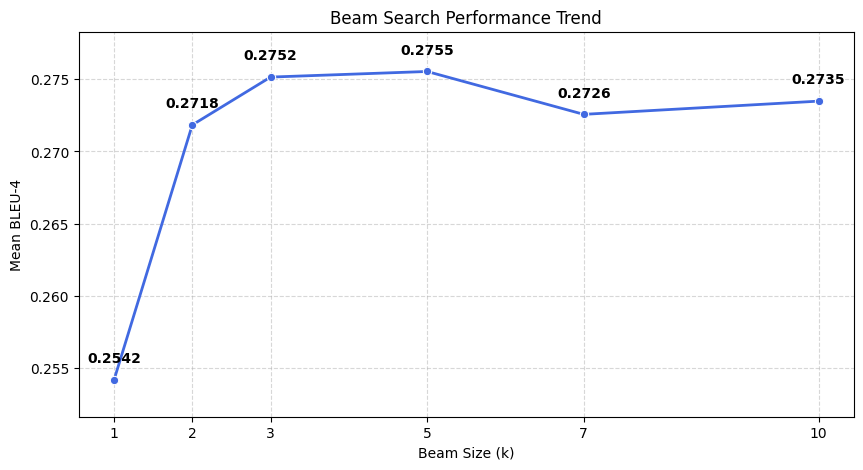

Mean Scores per k:
k
1     0.254154
2     0.271835
3     0.275152
5     0.275540
7     0.272568
10    0.273485
Name: BLEU-4, dtype: float64


In [ ]:
# Reshape data for visualization
melted_df = df_results.melt(
    id_vars=['filename'], 
    value_vars=[f"bleu_k{k}" for k in k_values],
    var_name='k', 
    value_name='BLEU-4'
)
melted_df['k'] = melted_df['k'].str.replace('bleu_k', '').astype(int)

# Plot performance trends
plt.figure(figsize=(10, 5))
sns.lineplot(data=melted_df, x='k', y='BLEU-4', marker='o', color='royalblue', lw=2, errorbar=None)

# Plot annotations
stats = melted_df.groupby('k')['BLEU-4'].mean()
for x, y in stats.items():
    plt.text(x, y + 0.001, f'{y:.4f}', ha='center', va='bottom', weight='bold')

plt.title('Beam Search Performance Trend', fontsize=12)
plt.xlabel('Beam Size (k)')
plt.ylabel('Mean BLEU-4')
plt.xticks(k_values)
plt.grid(True, ls='--', alpha=0.5)
plt.ylim(stats.min() * 0.99, stats.max() * 1.01)
plt.show()

print("Mean Scores per k:")
print(stats)

<a id="analiza-jakosciowa-demonstracja-przypadkow-gdzie-jest-najwieksza-roznica-pomiedzy-beam-search-a-greedy-search"></a>
### Analiza jakościowa: Demonstracja przypadków gdzie jest największa różnica pomiędzy Beam Search a Greedy Search 

Wybieramy 3 obrazy z największą różnicą BLEU-4 między `k=1` a `k=5`. Pokazujemy obok siebie opis Greedy Search i opis z Beam Search - co pozwala ocenić jakie błędy naprawia Beam Search (np. pominięte słowa, urwane zdania, zła kolejność).

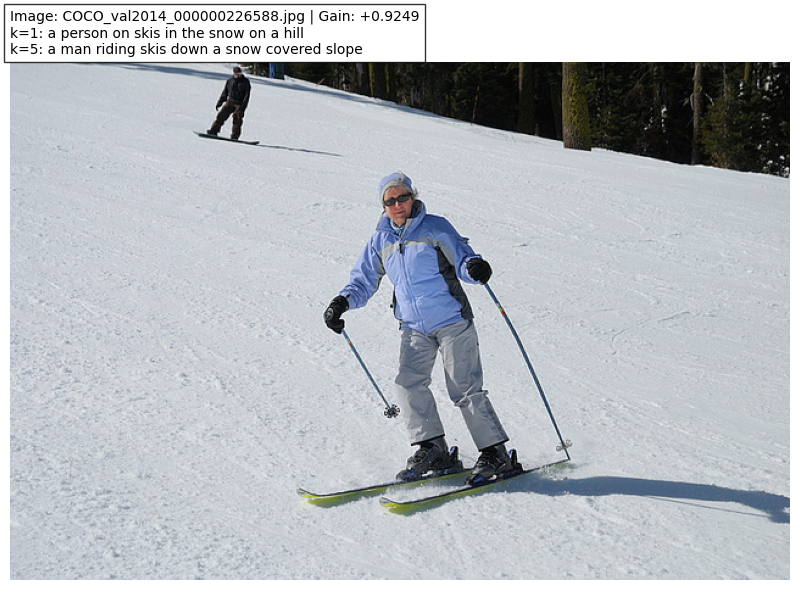

--------------------------------------------------------------------------------


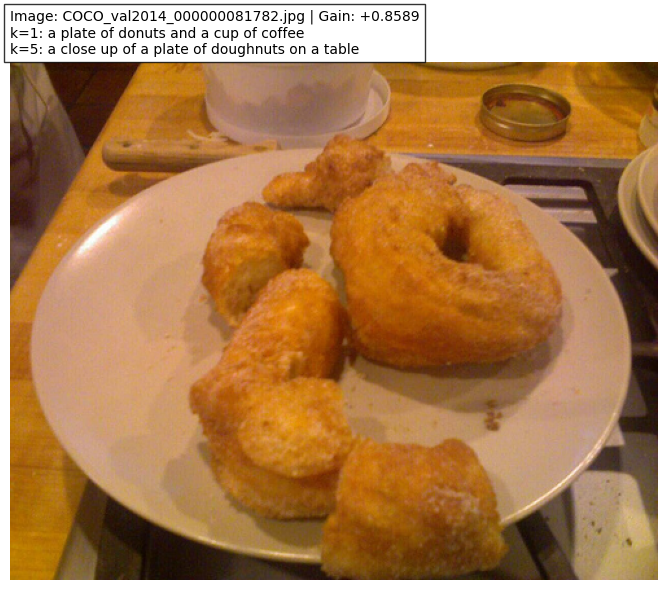

--------------------------------------------------------------------------------


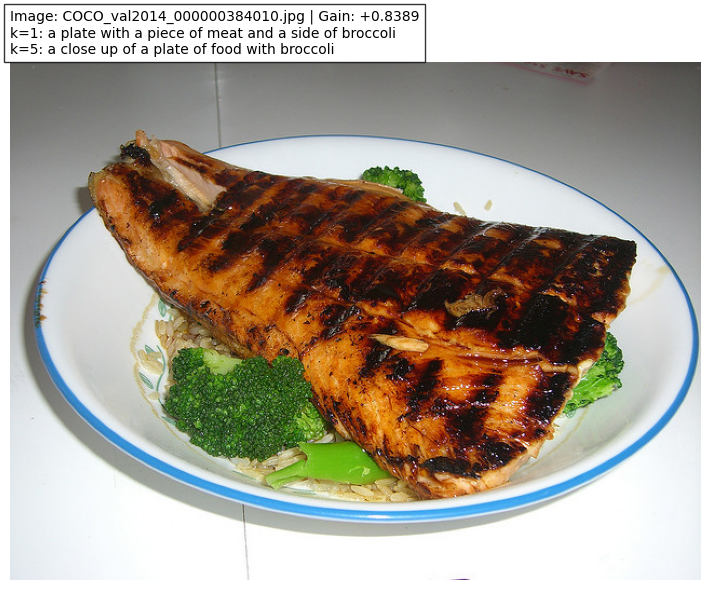

--------------------------------------------------------------------------------


In [ ]:
# Identify top 3 cases where k=5 outperformed k=1
df_results['delta'] = df_results['bleu_k5'] - df_results['bleu_k1']
showcase = df_results.sort_values(by='delta', ascending=False).head(3)

for _, row in showcase.iterrows():
    img = plt.imread(os.path.join("../dataset/val2014", row['filename']))
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    
    meta = (f"Image: {row['filename']} | Gain: +{row['delta']:.4f}\n"
            f"k=1: {row['cap_k1']}\n"
            f"k=5: {row['cap_k5']}")
    
    plt.title(meta, fontsize=10, loc='left', bbox=dict(facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()
    print("-" * 80)

<a id="wnioski"></a>
### Wnioski
**Obserwacje:**
- Beam Search wyraźnie przewyższa Greedy już przy `k=2`
- Dalszy wzrost `k` powyżej 3 nie daje istotnej poprawy
- Dla `k=7` i `k=10` BLEU-4 lekko spada, co sugeruje że model zaczyna preferować
  zdania o wysokim prawdopodobieństwie kosztem dopasowania do referencji
- Optymalny kompromis jakość/koszt: **`k=3`** - używany we wszystkich pozostałych eksperymentach

**Ograniczenia:** BLEU-4 mierzy n-gramowe pokrycie, nie semantykę. Opis poprawny
semantycznie ale inaczej sformułowany dostanie niski BLEU - dlatego analiza
jakościowa jest też ważna.

<a id="wizualizacja-mechanizmu-uwagi"></a>
## Wizualizacja mechanizmu uwagi

Jakościowa analiza mechanizmu uwagi (*attention*) - sprawdzenie czy model podczas generowania każdego słowa faktycznie "patrzy" na właściwy region obrazu.

Jest to eksperyment czysto jakościowy: nie liczymy żadnej metryki, tylko wizualnie oceniamy czy mapa uwagi pokrywa się z opisywanym obiektem.

In [ ]:
word_map_path = './dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
model_path = './checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'

In [ ]:
import sys
import os
import json
import torch

# Path alignment
sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search, visualize_att

# Device and Model setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(word_map_path, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(model_path, map_location=str(device), weights_only=False)
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

In [ ]:
custom_dir = "./dataset/my_test_images/experiment3"

# Load all images from directory
selected_files = [
    f for f in os.listdir(custom_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
]
selected_files.sort()

print(f"Found {len(selected_files)} images: {selected_files}")

Found 10 images: ['bike-in-the-forest.jpg', 'cars-in-a-parking-lot.jpg', 'cat-on-a-car.jpg', 'dog-on-a-beach.jpg', 'dog-on-a-skateboard.jpg', 'dog-on-grass.jpg', 'guy-with-parrot.jpg', 'horse-riding-through-the-desert.jpg', 'steak-on-a-plate.jpg', 'woman-with-broom.jpg']


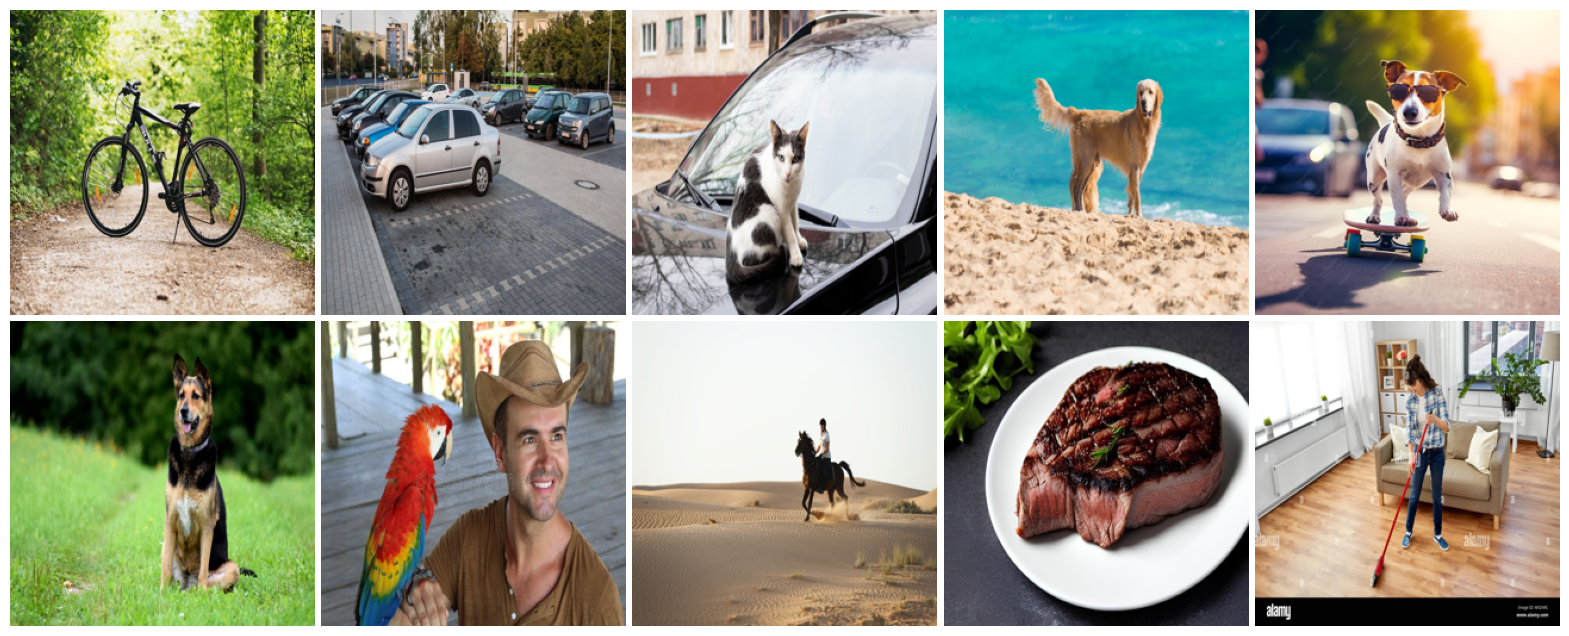

In [ ]:
# Visualize the images in a grid
from PIL import Image
import matplotlib.pyplot as plt
import math

cols = 5
rows = math.ceil(len(selected_files) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, fname in enumerate(selected_files):
    img = Image.open(os.path.join(custom_dir, fname)).convert('RGB').resize((256, 256))
    axes[i].imshow(img)
    axes[i].axis('off')

for j in range(len(selected_files), len(axes)):
    axes[j].axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

<a id="analiza-wygenerowane-opisy-i-mapy-uwagi"></a>
### Analiza: wygenerowane opisy i mapy uwagi

Dla każdego obrazu model generuje opis słowo po słowie. Pod każdym słowem widoczna jest mapa uwagi - jaśniejszy region = wyższa waga przy wyborze tego słowa.

Interesują nas dwa pytania:

1. Czy opis jest semantycznie poprawny?
2. Czy mapa uwagi wskazuje właściwy obiekt dla każdego słowa?

Analyzing 10 custom samples...


SOURCE: bike-in-the-forest.jpg
RESULT: a bike parked on top of a dirt road


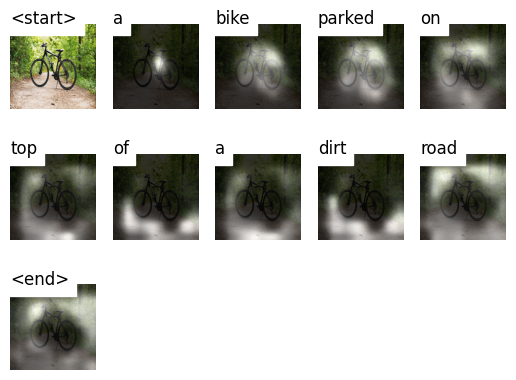


SOURCE: cars-in-a-parking-lot.jpg
RESULT: a car is parked in a parking lot


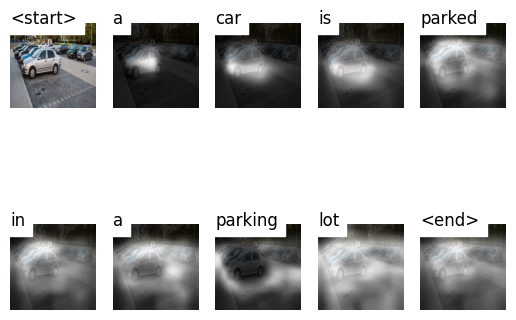


SOURCE: cat-on-a-car.jpg
RESULT: a cat sitting on the hood of a car


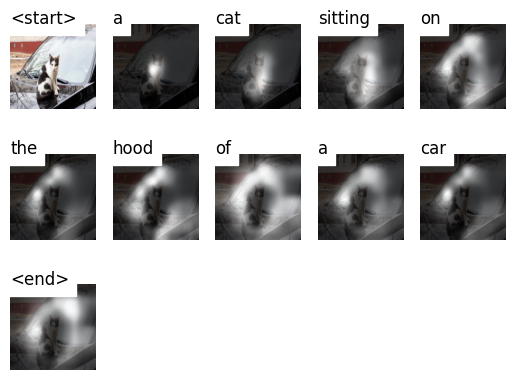


SOURCE: dog-on-a-beach.jpg
RESULT: a white dog standing on top of a sandy beach


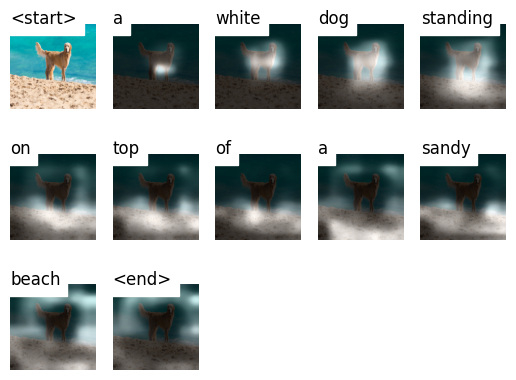


SOURCE: dog-on-a-skateboard.jpg
RESULT: a small dog is riding on a skateboard


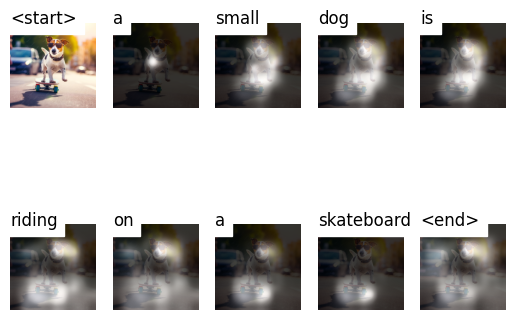


SOURCE: dog-on-grass.jpg
RESULT: a dog sitting in a field of grass


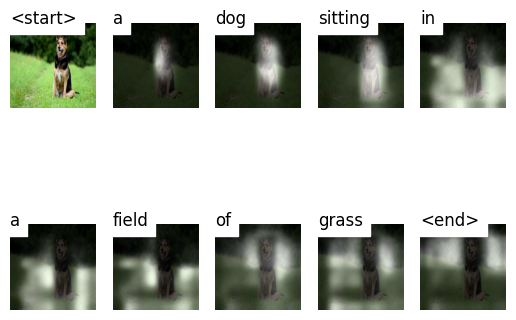


SOURCE: guy-with-parrot.jpg
RESULT: a man is holding a parrot on his head


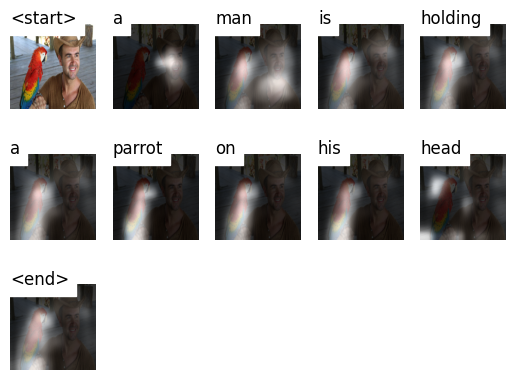


SOURCE: horse-riding-through-the-desert.jpg
RESULT: a person riding a horse on a beach


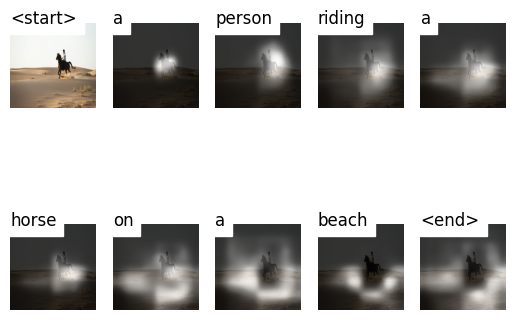


SOURCE: steak-on-a-plate.jpg
RESULT: a piece of chocolate cake on a white plate


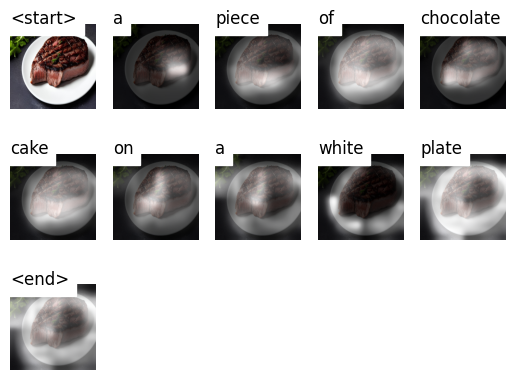


SOURCE: woman-with-broom.jpg
RESULT: a woman is playing a video game in a living room


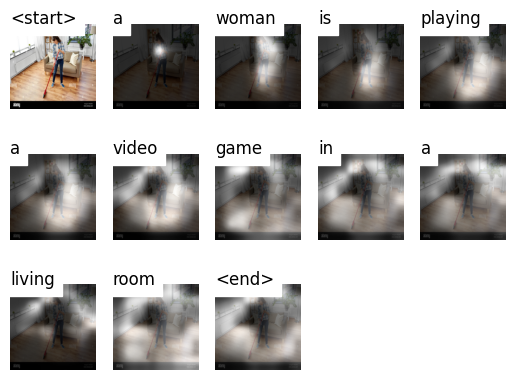

In [ ]:
def run_custom_attention_analysis(image_list, k=5):
    """
    Performs qualitative attention analysis on custom images.
    Visualizes how the model grounds linguistic tokens in visual regions.
    """
    print(f"Analyzing {len(image_list)} custom samples...\n")
    
    for filename in image_list:
        fpath = os.path.join(custom_dir, filename)
        
        if not os.path.exists(fpath):
            print(f"Skipping: {filename} (File not found at {fpath})")
            continue
            
        # Inference
        seq, alphas = caption_image_beam_search(encoder, decoder, fpath, word_map, k)
        
        # Sentence reconstruction
        caption = [rev_word_map[i] for i in seq if i not in 
                   {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        
        print(f"\n{'='*50}")
        print(f"SOURCE: {filename}")
        print(f"RESULT: {' '.join(caption)}")
        print(f"{'='*50}")
        
        # Attention visualization
        alphas_tensor = torch.FloatTensor(alphas)
        visualize_att(fpath, seq, alphas_tensor, rev_word_map, smooth=True)

# Run visualization
run_custom_attention_analysis(selected_files)

<a id="wnioski-1"></a>
### Wnioski

**Przypadki poprawne** (model rozpoznaje właściwe obiekty):
- `dog-on-a-beach.jpg` -> *"a white dog standing on top of a sandy beach"* - uwaga przesuwa się od psa do piasku zgodnie z generowanymi słowami
- `dog-on-a-skateboard.jpg` -> *"a small dog is riding on a skateboard"* - model poprawnie identyfikuje zarówno psa jak i deskorolkę
- `dog-on-grass.jpg` -> *"a dog sitting in a field of grass"* - poprawne
- `bike-in-the-forest.jpg` -> *"a bike parked on top of a dirt road"* - poprawne
- `cars-in-a-parking-lot.jpg` -> *"a car is parked in a parking lot"* - poprawne
- `cat-on-a-car.jpg` -> *"a cat sitting on the hood of a car"* - poprawne

**Przypadki błędów atrybutów** (obiekt rozpoznany, ale cecha błędna):
- `guy-with-parrot.jpg` -> *"a man is holding a parrot on his head"* - model poprawnie rozpoznał mężczyznę i papugę, ale błędnie określił relację przestrzenną: papuga siedzi na barku, nie na głowie

**Przypadki halucynacji** (model myli obiekty):
- `steak-on-a-plate.jpg` -> *"a piece of chocolate cake on a white plate"* - stek pomylony z ciastem czekoladowym (podobna brązowa, nieregularna forma)
- `horse-riding-through-the-desert.jpg` -> *"a person riding a horse on a beach"* - pustynia pomylona z plażą (piasek, brak roślinności - zbliżone cechy wizualne)
- `woman-with-broom.jpg` -> *"a woman is playing a video game in a living room"* - kobieta zamiatająca podłogę opisana jako grająca w grę wideo; model zignorował
  miotłę i oparł się na kontekście pomieszczenia

**Kluczowa obserwacja:**
Model radzi sobie dobrze z obiektami częstymi w MS COCO i prostymi scenami (psy, rowery, samochody, koty). 

Kobieta z miotłą jest interesującym przypadkiem: model całkowicie zignorował miotłę i sklasyfikował scenę na podstawie samego tła (salon), co sugeruje że kontekst sceny może czasami dominować nad lokalnymi cechami obiektów.

<a id="krytyczna-analiza"></a>
# Krytyczna analiza
<!-- TODO: (podsumowanie weryfikacji eksperymentalnej) -->

<a id="wnioski-2"></a>
# Wnioski
<!-- głównie w zakresie stosowalności metody na podstawie własnych eksperymentów - kiedy się sprawdza, kiedy nie itd.  -->